<a href="https://colab.research.google.com/github/vittoriobu/neuroanalysis2026/blob/main/calcium_imaging_exercises_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calcium Imaging exercise 1 in colab



## Caiman setup / drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%mkdir -p neuroanalysis
%cd neuroanalysis

/content/neuroanalysis


In [ ]:
# Install CaImAn
!git clone https://github.com/flatironinstitute/CaImAn.git
%cd 'CaImAn/'

Cloning into 'CaImAn'...
remote: Enumerating objects: 30638, done.
remote: Counting objects: 100% (7915/7915), done.
remote: Compressing objects: 100% (2593/2593), done.
remote: Total 30638 (delta 5477), reused 5322 (delta 5322), pack-reused 22723 (from 3)
Receiving objects: 100% (30638/30638), 646.46 MiB | 25.21 MiB/s, done.
Resolving deltas: 100% (20603/20603), done.
Updating files: 100% (228/228), done.
/content/neuroanalysis/CaImAn


In [ ]:

# %cd '/content/neuroanalysis/CaImAn/'

In [ ]:
from datetime import datetime
import scipy.io as sio
import re
import os
import h5py
import csv
import tensorflow as tf
import time
import logging
import zipfile
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use('default')
import numpy as np
from moviepy.editor import *
import smtplib

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
!pip install jupyterlab numpy scipy matplotlib seaborn PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.4 MB/s eta 0:00:00


In [ ]:
!pip install -e .

Obtaining file:///content/neuroanalysis/CaImAn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.9/174.9 MB 4.4 MB/s e

In [ ]:
%cd /content/neuroanalysis
! git clone https://github.com/neural-data-science-course/neural-data.git

/content/neuroanalysis
Cloning into 'neural-data'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 238 (delta 38), reused 51 (delta 18), pack-reused 137 (from 1)
Receiving objects: 100% (238/238), 41.59 MiB | 14.28 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [ ]:
%cd neural-data

/content/neuroanalysis/neural-data


In [ ]:
%cd 02-calcium_imaging

/content/neuroanalysis/neural-data/02-calcium_imaging


In [ ]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

import sys
# Add the CaImAn directory to sys.path
sys.path.append(os.path.abspath('/content/neuroanalysis/CaImAn'))

# CaImAn functions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

# Original sys.path append for local code
sys.path.append(os.path.abspath("code"))
from utils import download_data
import auxiliary_functions as aux

import seaborn as sns
sns.set_theme(context='notebook', style='white', font_scale=1.5)

In [ ]:
# download data for the lesson (this can take a few minutes)
# download_data('https://surfdrive.surf.nl/index.php/s/HeYXPdvMO87fbq7')

#!!!! as of 27/4/2026 the link didn't work, I asked around to send the original files to me

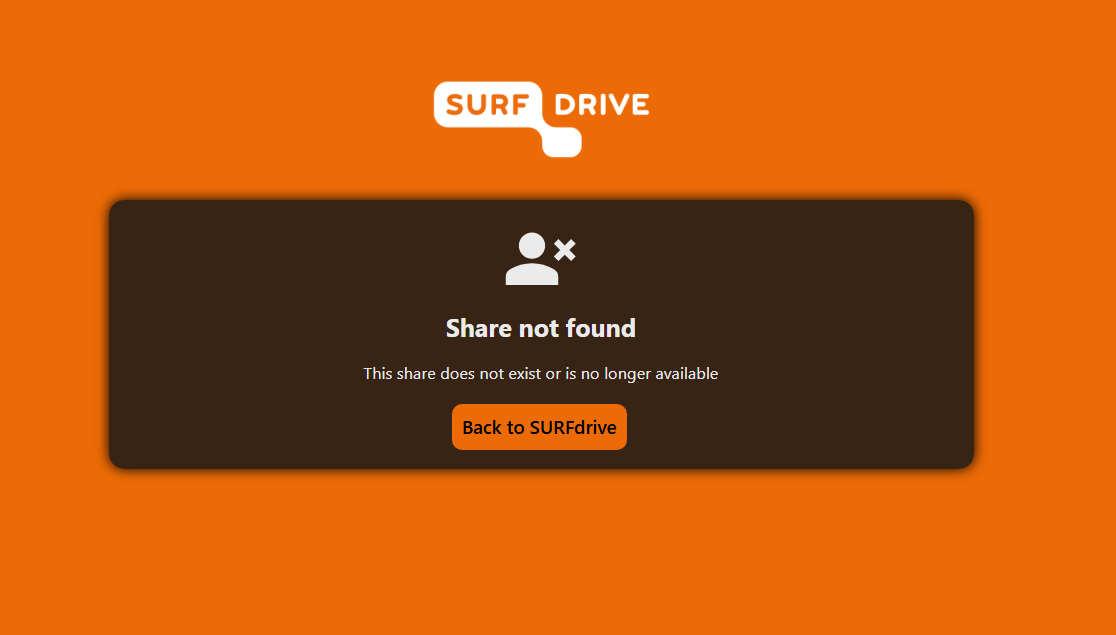

## Load and visualize the video

In [ ]:
# set path to video of the full field of view
input_tif_file_path_FOV = '/content/drive/MyDrive/data/calcium_video.tif'
input_tif_file_path = '/content/drive/MyDrive/data/caiman_video_trial_0.tif'

In [ ]:
FOV = cm.load(input_tif_file_path_FOV)  # load video with complete field of view (FOV)

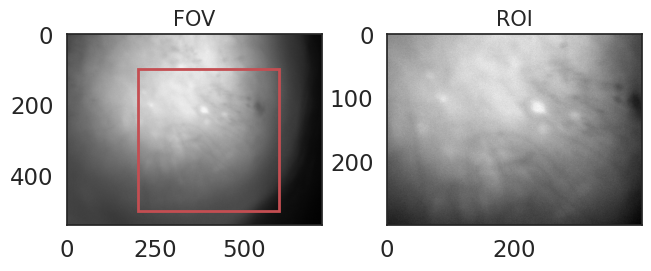

In [ ]:
# visualization of the FOV and the ROI
aux.plot_FOV(FOV_file=input_tif_file_path_FOV, ROI_file=input_tif_file_path)

## Summary Images

In [ ]:
# load movie and compute summary images with caiman functions
original_movie = cm.load(input_tif_file_path)
mean_image = cm.summary_images.mean_image(input_tif_file_path)
correlation_image, pnr_image = cm.summary_images.correlation_pnr(original_movie, swap_dim=False)

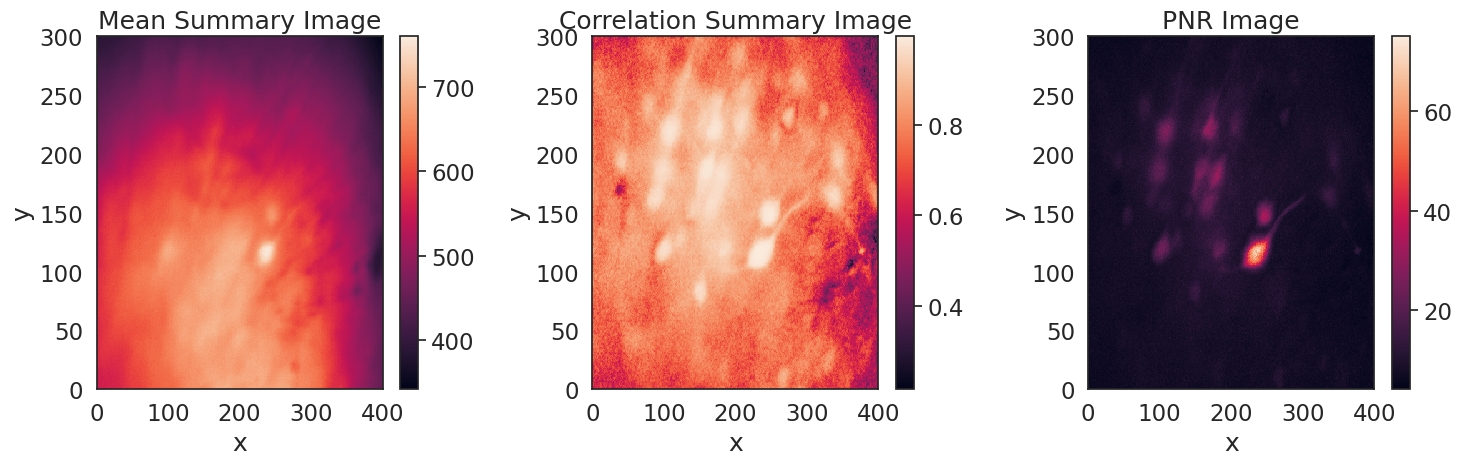

In [ ]:
# Plot summary images
figure, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('Mean Summary Image')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].set_title('Correlation Summary Image')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y'); axes[2].set_title('PNR Image')

mesh0 = axes[0].pcolormesh(mean_image)
mesh1 = axes[1].pcolormesh(correlation_image)
mesh2 = axes[2].pcolormesh(pnr_image)

figure.colorbar(mesh0, ax=axes[0])
figure.colorbar(mesh1, ax=axes[1])
figure.colorbar(mesh2, ax=axes[2])
plt.tight_layout()

------------
## Exercise 1 : Image characteristics

### Exercise 1A - Distinguishing pixels

Select a set of N random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are chosen from an active neuron, you will be able to see the calcium transient dynamic. Try this a few times to appreciate the results.

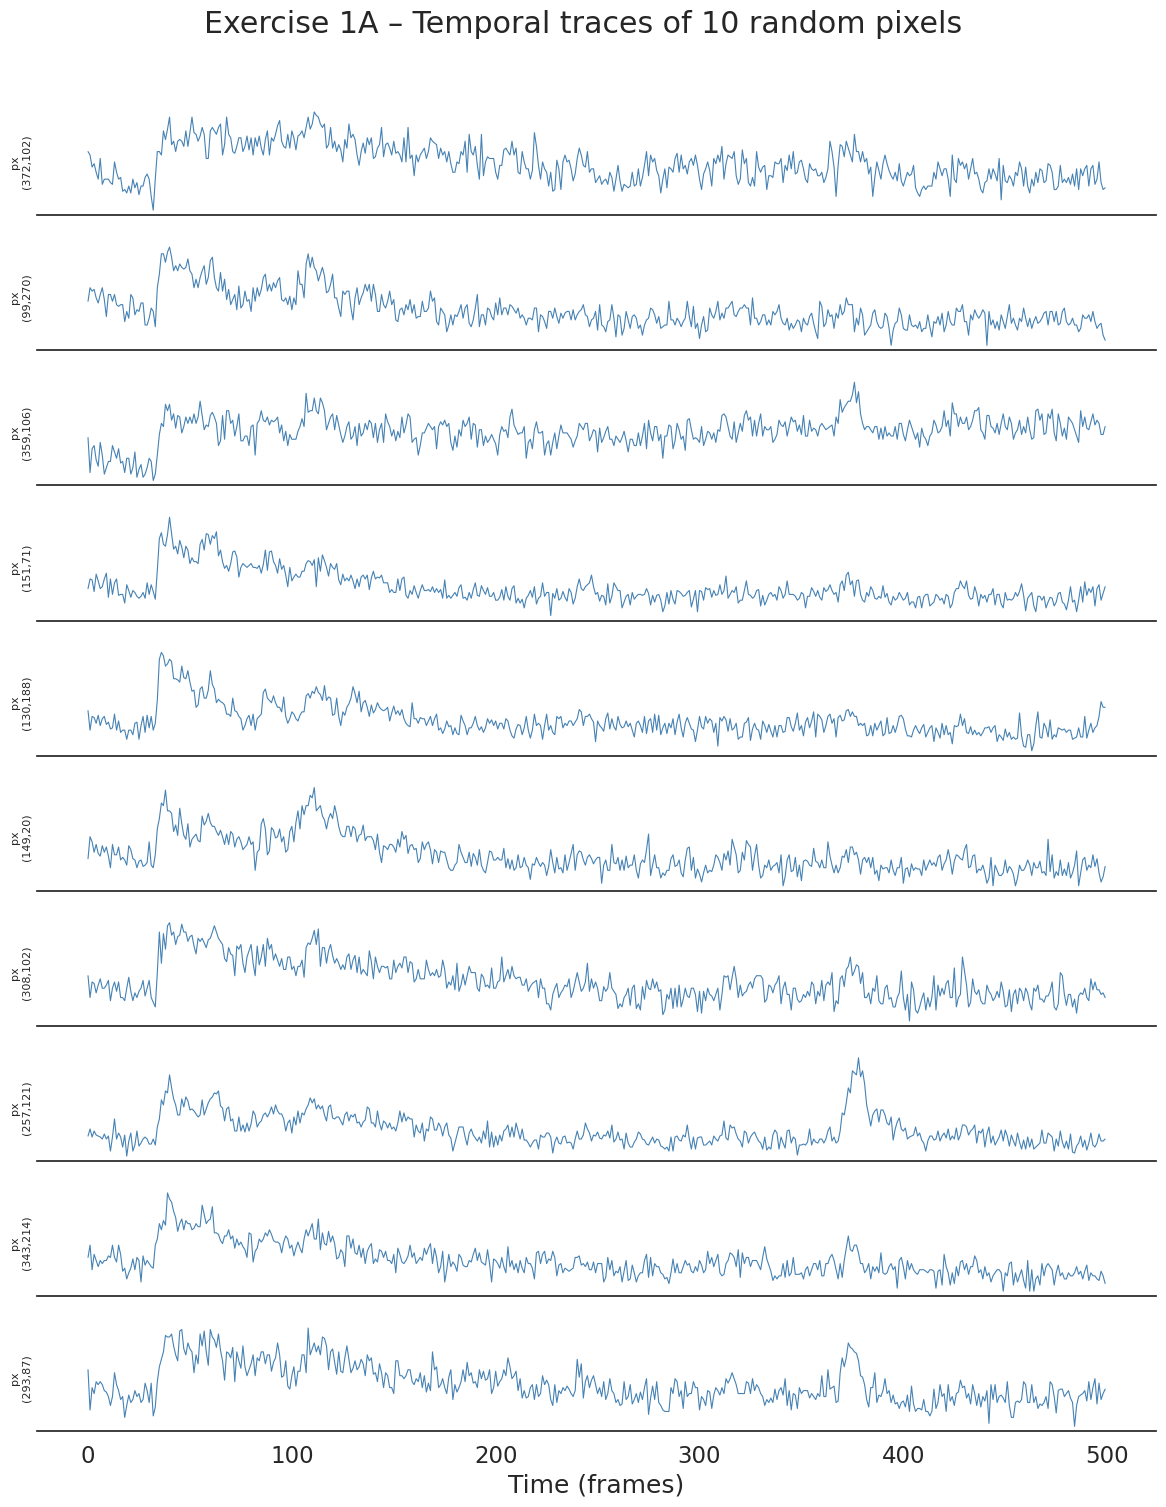

In [ ]:
# Exercise 1A , Temporal traces of random pixels

N = 10  # number of random pixels to sample
n_frames, height, width = original_movie.shape

# randomly select N pixel coordinates within the ROI
np.random.seed(42)  # change or remove seed to get different pixels each run
random_y = np.random.randint(0, height, size=N)
random_x = np.random.randint(0, width, size=N)

# extract temporal traces for each selected pixel
pixel_traces = [original_movie[:, random_y[i], random_x[i]] for i in range(N)]

# plot temporal traces
figure, axes = plt.subplots(N, 1, figsize=(12, N * 1.5), sharex=True)
time_axis = np.arange(n_frames)
for i in range(N):
    axes[i].plot(time_axis, pixel_traces[i], lw=0.8, color='steelblue')
    axes[i].set_ylabel(f'px\n({random_x[i]},{random_y[i]})', fontsize=8)
    axes[i].set_yticks([])
    sns.despine(ax=axes[i], left=True)
axes[-1].set_xlabel('Time (frames)')
figure.suptitle(f'Exercise 1A – Temporal traces of {N} random pixels', y=1.01)
plt.tight_layout()

### Exercise 1 b : temporal Statistics of Pixel Activation

For the selected pixels, plot the histogram of pixel value. What are the differences in different regions, and how can that help to distinguish a pixel that belongs to a neuron from a background pixel?



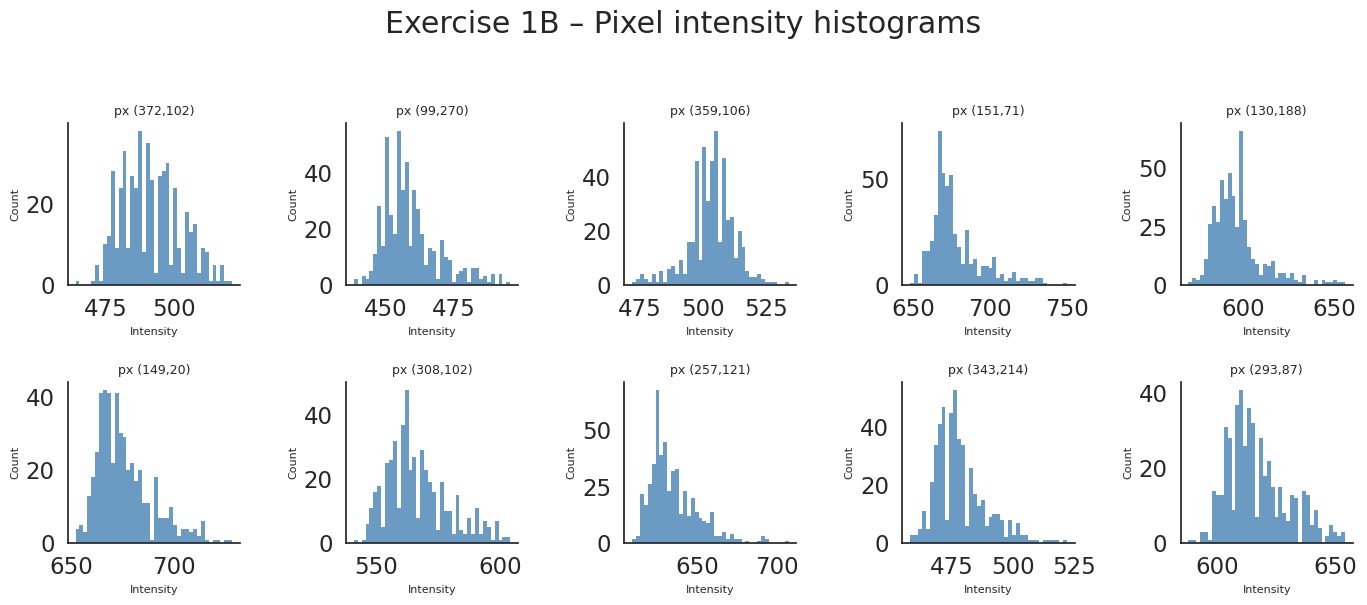

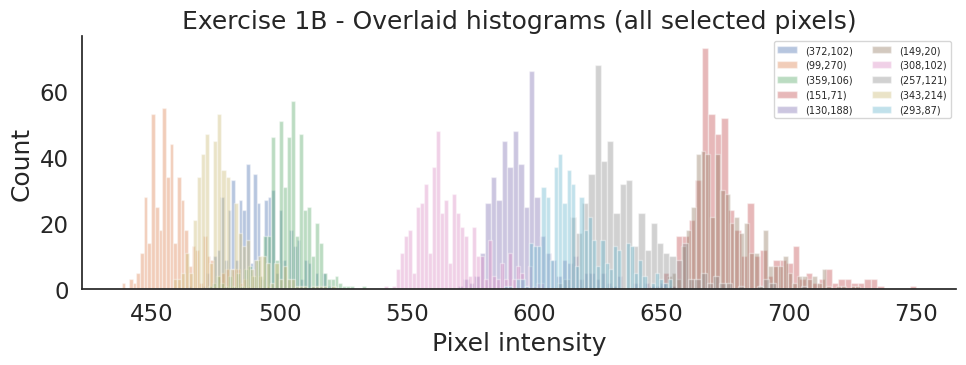

In [ ]:
# Exercise 1B - Histograms of pixel values for the selected pixels

figure, axes = plt.subplots(2, N // 2, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i in range(N):
    axes[i].hist(pixel_traces[i], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'px ({random_x[i]},{random_y[i]})', fontsize=9)
    axes[i].set_xlabel('Intensity', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    sns.despine(ax=axes[i])

figure.suptitle('Exercise 1B – Pixel intensity histograms', y=1.02)
plt.tight_layout()

# overlay all histograms for comparison
figure2, ax2 = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax2.hist(pixel_traces[i], bins=40, alpha=0.4,
             label=f'({random_x[i]},{random_y[i]})')
ax2.set_xlabel('Pixel intensity')
ax2.set_ylabel('Count')
ax2.set_title('Exercise 1B - Overlaid histograms (all selected pixels)')
ax2.legend(fontsize=7, ncol=2)
sns.despine()
plt.tight_layout()

## Exercise 2 : Motion correction

In [ ]:
# Define parameters for motion correction in a dictionary

parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True,
                                'use_cuda': False,
                                'nonneg_movie': True,
                                'border_nan': 'copy'}

original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie)
Path('data/motion_corrected').mkdir(parents=True, exist_ok=True)
opts = params.CNMFParams(params_dict = parameters_motion_correction)


In [ ]:
n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

In [ ]:

#create an object for motion correction
mc = MotionCorrect(input_tif_file_path, dview = dview, **opts.get_group('motion'))
# Perform rigid motion correction
mc.motion_correct_rigid(save_movie = True, template = None)

#perform non-rigid motion correction
total_template_rig = mc.total_template_rig
mc.motion_correct_pwrigid(save_movie=True, template = total_template_rig)
fname_tot_els = mc.fname_tot_els[0]

#reshape memmap files for source extraction
m_els = cm.load(fname_tot_els)
fname_tot_els  = m_els.save('motion_corrected_video.mmap',  order='C')
# Path(fname_tot_els).rename(f"data/motion_corrected/{fname_tot_els}")

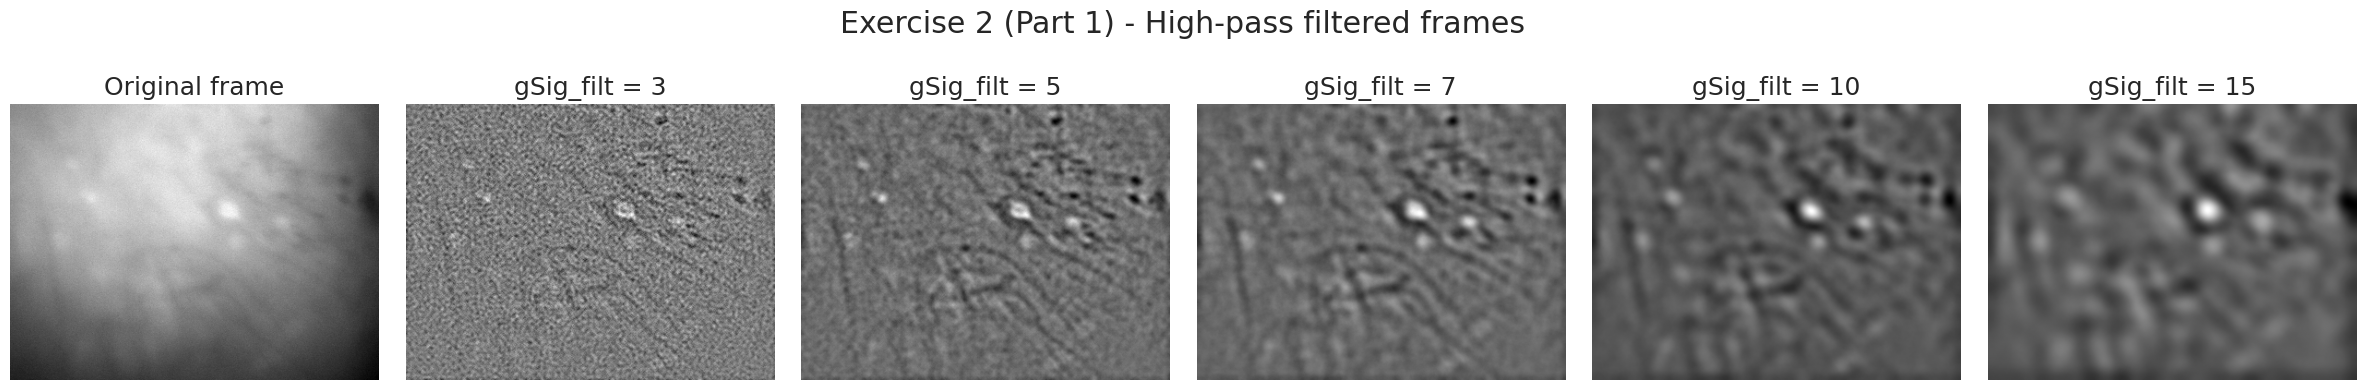

In [ ]:
#high_pass_filter_space on a single frame
from caiman.motion_correction import high_pass_filter_space

frame = np.array(original_movie[0], dtype=np.float32)   # first frame
gSig_filters_vis = [3, 5, 7, 10, 15]                    # filter sizes to visualise

fig, axes = plt.subplots(1, len(gSig_filters_vis) + 1,
                          figsize=(4 * (len(gSig_filters_vis) + 1), 4))
axes[0].imshow(frame, cmap='gray')
axes[0].set_title('Original frame')
axes[0].axis('off')

for ax, gs in zip(axes[1:], gSig_filters_vis):
    filtered = high_pass_filter_space(frame, (gs, gs))
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'gSig_filt = {gs}')
    ax.axis('off')

fig.suptitle('Exercise 2 (Part 1) - High-pass filtered frames', y=1.01)
plt.tight_layout()

In [ ]:
def run_mc_get_crispness(tif_path, mc_params, dview):

    opts = params.CNMFParams(params_dict=mc_params)
    mc = MotionCorrect(tif_path, dview=dview, **opts.get_group('motion'))
    mc.motion_correct_rigid(save_movie=True, template=None)
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    final_size = mc.total_template_els.shape
    winsize = 100
    swap_dim = False
    resize_fact_flow = 0.1
    _, _, _, _, crispness_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)
    _, _, _, _, crispness_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow)

    return crispness_rig, crispness_els

In [ ]:
#Sweep gSig_filt values, record crispness
gSig_filt_values = [3, 5, 7]

crisp_rig_gsig  = []
crisp_els_gsig  = []

# also compute baseline crispness of the original (no correction)
crisp_original = cm.motion_correction.compute_metrics_motion_correction(
    input_tif_file_path,
    *cm.load(input_tif_file_path)[0].shape[:2],
    False, winsize=100, play_flow=False, resize_fact_flow=0.1)

for gs in gSig_filt_values:
    print(f'Running MC with gSig_filt={gs} ...')
    p = parameters_motion_correction.copy()
    p['gSig_filt'] = (gs, gs)
    cr, ce = run_mc_get_crispness(input_tif_file_path, p, dview)
    crisp_rig_gsig.append(cr)
    crisp_els_gsig.append(ce)
    print(f'  rigid={cr:.1f}  pw-rigid={ce:.1f}')



Running MC with gSig_filt=3 ...


  rigid=1046.5  pw-rigid=1044.6
Running MC with gSig_filt=5 ...


  rigid=858.7  pw-rigid=882.9
Running MC with gSig_filt=7 ...


  rigid=826.3  pw-rigid=866.3


TypeError: unsupported format string passed to tuple.__format__

In [ ]:
crisp_original = float(crisp_original[-1])  # extract the last element (the crispness scalar)
print(f'Original (no MC): crispness = {crisp_original:.1f}')

Original (no MC): crispness = 1059.4


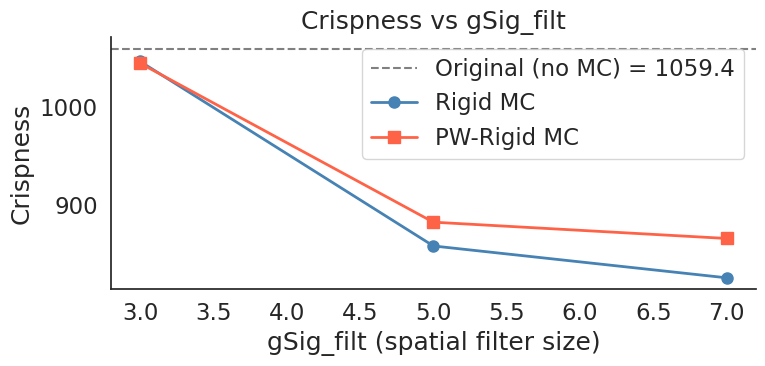

In [ ]:
#Plot crispness vs gSig_filt

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(crisp_original, color='gray', ls='--', lw=1.5,
           label=f'Original (no MC) = {crisp_original:.1f}')
ax.plot(gSig_filt_values, crisp_rig_gsig, 'o-', color='steelblue',
        lw=2, ms=8, label='Rigid MC')
ax.plot(gSig_filt_values, crisp_els_gsig, 's-', color='tomato',
        lw=2, ms=8, label='PW-Rigid MC')
ax.set_xlabel('gSig_filt (spatial filter size)')
ax.set_ylabel('Crispness')
ax.set_title('Crispness vs gSig_filt')
ax.legend()
sns.despine()
plt.tight_layout()

In [ ]:
#Sweep max_shifts, fixed gSig_filt=(5,5)
max_shifts_values = [5, 10, 15, 25, 40]

crisp_rig_shifts  = []
crisp_els_shifts  = []

for ms in max_shifts_values:
    print(f'Running MC with max_shifts={ms} ...')
    p = parameters_motion_correction.copy()
    p['max_shifts'] = (ms, ms)
    p['max_deviation_rigid'] = ms
    cr, ce = run_mc_get_crispness(input_tif_file_path, p, dview)
    crisp_rig_shifts.append(cr)
    crisp_els_shifts.append(ce)
    print(f'  rigid={cr:.1f}  pw-rigid={ce:.1f}')

Running MC with max_shifts=5 ...


  rigid=859.9  pw-rigid=882.4
Running MC with max_shifts=10 ...


  rigid=858.9  pw-rigid=882.6
Running MC with max_shifts=15 ...


  rigid=858.9  pw-rigid=882.7
Running MC with max_shifts=25 ...


  rigid=858.7  pw-rigid=882.9
Running MC with max_shifts=40 ...


  rigid=857.2  pw-rigid=883.1


How will this filtering affect the measure of crispness?

 Higher spatial filtering (larger gSig_filt) removes low-frequency background and sharpens borders, which tends to increase crispness. However, over-filtering can blur meaningful structure and reduce crispness again, there is an optimal filter size.